# Metrics Analysis — Tomato Instance Segmentation

Compile and visualise training metrics, COCO evaluation results, and training
efficiency across all experiment variants in the `output/` directory.

**Sections**
- **A** Training loss curves
- **B** Training efficiency (speed & data-loading overhead)
- **C** COCO segmentation evaluation (AP / AR)
- **D** Summary table & heatmap

In [1]:
import json
import re
import warnings
from contextlib import redirect_stdout, redirect_stderr
from io import StringIO
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

OUTPUT_DIR = Path("output")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Colour palette — one hue per fusion family
FAMILY_COLORS = {
    "baseline":     "#1f77b4",
    "early":        "#ff7f0e",
    "bicma":        "#2ca02c",
    "bicma_alpha":  "#d62728",
    "dca":          "#9467bd",
    "dca_multihead":"#8c564b",
}
SMOOTH = 15  # rolling-window size for loss curves

## Experiment Registry

In [2]:
def parse_exp_name(name: str) -> dict:
    meta = {"name": name}
    meta["modality"] = "rgbd" if name.startswith("rgbd_") else "rgb"

    if "dca_multihead" in name:
        meta["fusion"] = "dca_multihead"
    elif "dca" in name:
        meta["fusion"] = "dca"
    elif "bicma_alpha" in name:
        meta["fusion"] = "bicma_alpha"
    elif "bicma" in name:
        meta["fusion"] = "bicma"
    elif "early" in name:
        meta["fusion"] = "early"
    else:
        meta["fusion"] = "baseline"

    # Two naming conventions: _iterN  and  _Niter
    m = re.search(r"_iter(\d+)", name)
    if m:
        meta["dca_iters"] = int(m.group(1))
    else:
        m = re.search(r"_(\d+)iter", name)
        meta["dca_iters"] = int(m.group(1)) if m else None

    m = re.search(r"_h(\d+)_", name)
    meta["heads"] = int(m.group(1)) if m else None

    m = re.search(r"_gw(\d+)_(\d+)", name)
    meta["gw"] = float(f"{m.group(1)}.{m.group(2)}") if m else None

    return meta


exp_dirs = sorted(
    [d for d in OUTPUT_DIR.iterdir() if d.is_dir() and (d / "metrics.json").exists()]
)
registry = pd.DataFrame([parse_exp_name(d.name) for d in exp_dirs]).set_index("name")
registry["path"] = exp_dirs

print(f"Found {len(registry)} experiments")
registry[["modality", "fusion", "dca_iters", "heads", "gw"]].fillna("-")

Found 21 experiments


,modality,fusion,dca_iters,heads,gw
name,,,,,
rgb_gw2_0_mi5000_swin_tiny,rgb,baseline,-,-,2.0
rgb_swin_tiny,rgb,baseline,-,-,-
rgbd_bicma_alpha_swin_tiny,rgbd,bicma_alpha,-,-,-
rgbd_bicma_alpha_swin_tiny_1iter,rgbd,bicma_alpha,1.0,-,-
rgbd_bicma_alpha_swin_tiny_2iter,rgbd,bicma_alpha,2.0,-,-
rgbd_bicma_alpha_swin_tiny_3iter,rgbd,bicma_alpha,3.0,-,-
rgbd_bicma_swin_tiny,rgbd,bicma,-,-,-
rgbd_dca_1iter_swin_tiny,rgbd,dca,1.0,-,-
rgbd_dca_iter0_gw2_0_mi5000_swin_tiny,rgbd,dca,0.0,-,2.0


## Section A — Training Loss Curves

In [3]:
def load_metrics(exp_path: Path) -> pd.DataFrame:
    rows = []
    with open(exp_path / "metrics.json") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    df = pd.DataFrame(rows)
    df["exp"] = exp_path.name
    return df


all_metrics = pd.concat(
    [load_metrics(d) for d in exp_dirs], ignore_index=True
)
print(
    f"Loaded {len(all_metrics):,} metric rows "
    f"from {all_metrics['exp'].nunique()} experiments"
)

Loaded 5,542 metric rows from 19 experiments


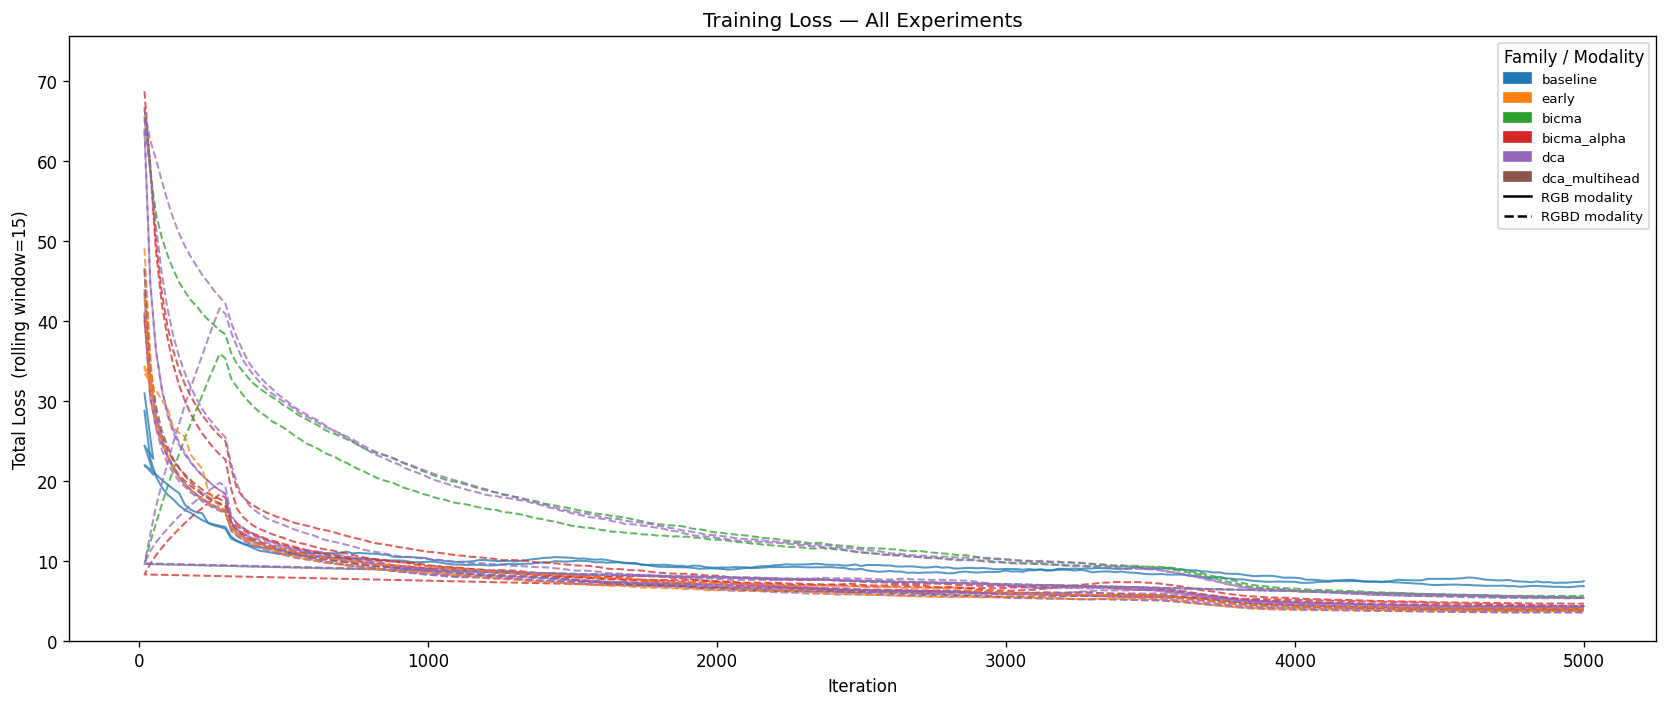

In [4]:
def smooth(series, window=SMOOTH):
    return series.rolling(window, min_periods=1).mean()


fig, ax = plt.subplots(figsize=(14, 6))

for exp_name, grp in all_metrics.groupby("exp"):
    meta = registry.loc[exp_name]
    color = FAMILY_COLORS[meta["fusion"]]
    ls = "-" if meta["modality"] == "rgb" else "--"
    s = smooth(grp.set_index("iteration")["total_loss"])
    ax.plot(s.index, s.values, color=color, linestyle=ls, alpha=0.75, linewidth=1.2)

ax.set_xlabel("Iteration")
ax.set_ylabel(f"Total Loss  (rolling window={SMOOTH})")
ax.set_title("Training Loss — All Experiments")
ax.set_ylim(bottom=0)

family_handles = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
style_handles = [
    Line2D([0], [0], color="k", ls="-",  label="RGB modality"),
    Line2D([0], [0], color="k", ls="--", label="RGBD modality"),
]
ax.legend(handles=family_handles + style_handles,
          loc="upper right", fontsize=8, title="Family / Modality")
plt.tight_layout()
plt.savefig(FIG_DIR / "total_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

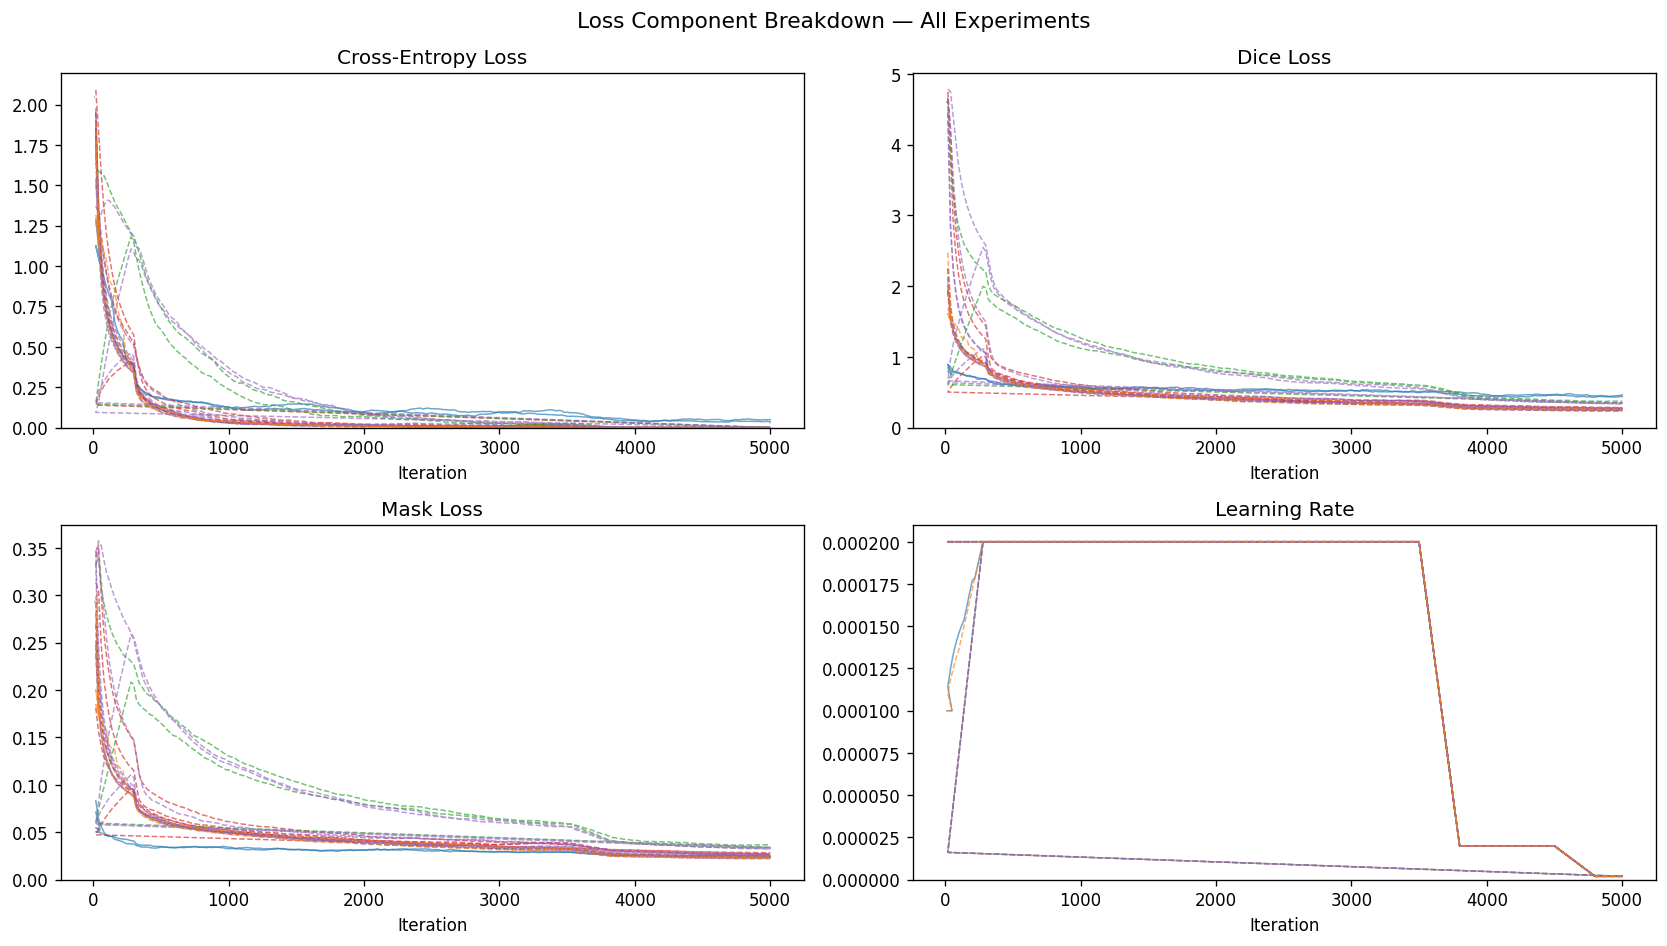

In [5]:
COMPONENTS = [
    ("loss_ce",   "Cross-Entropy Loss"),
    ("loss_dice", "Dice Loss"),
    ("loss_mask", "Mask Loss"),
    ("lr",        "Learning Rate"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (col, title) in zip(axes.flat, COMPONENTS):
    for exp_name, grp in all_metrics.groupby("exp"):
        if col not in grp.columns:
            continue
        meta = registry.loc[exp_name]
        s = smooth(grp.set_index("iteration")[col])
        ax.plot(s.index, s.values,
                color=FAMILY_COLORS[meta["fusion"]],
                linestyle="-" if meta["modality"] == "rgb" else "--",
                alpha=0.65, linewidth=0.9)
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylim(bottom=0)

fig.suptitle("Loss Component Breakdown — All Experiments", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "loss_components.png", dpi=150, bbox_inches="tight")
plt.show()

## Section B — Training Efficiency

In [6]:
eff_rows = []
for exp_name, grp in all_metrics.groupby("exp"):
    last20 = grp.nlargest(20, "iteration")
    p10 = grp["total_loss"].quantile(0.10)
    below = grp[grp["total_loss"] <= p10]
    conv_iter = int(below["iteration"].min()) if len(below) > 0 else None

    eff_rows.append({
        "exp":               exp_name,
        "mean_iter_time_s":  grp["time"].mean(),
        "mean_data_time_s":  grp["data_time"].mean(),
        "data_load_pct":     100 * grp["data_time"].mean() / grp["time"].mean(),
        "total_train_h":     grp["time"].sum() / 3600,
        "n_iters":           int(grp["iteration"].max()),
        "final_total_loss":  last20["total_loss"].mean(),
        "convergence_iter":  conv_iter,
    })

eff_df = pd.DataFrame(eff_rows).set_index("exp")
eff_df = eff_df.join(registry[["modality", "fusion"]])
eff_df.sort_values("mean_iter_time_s").round(3)

,mean_iter_time_s,mean_data_time_s,data_load_pct,total_train_h,n_iters,final_total_loss,convergence_iter,modality,fusion
exp,,,,,,,,,
rgbd_early_swin_tiny,0.391,0.008,2.011,0.028,5000,3.977,3999,rgbd,early
rgbd_dca_swin_tiny,0.415,0.008,1.836,0.086,5000,4.958,3559,rgbd,dca
rgbd_bicma_alpha_swin_tiny_1iter,0.424,0.008,1.794,0.029,5000,3.844,3999,rgbd,bicma_alpha
rgbd_bicma_swin_tiny,0.477,0.008,1.657,0.066,5000,5.509,4179,rgbd,bicma
rgbd_early_gw2_0_mi5000_swin_tiny,0.494,0.011,2.262,0.034,5000,3.720,3999,rgbd,early
rgbd_dca_iter0_gw2_0_mi5000_swin_tiny,0.523,0.011,2.168,0.036,5000,3.590,4119,rgbd,dca
rgbd_dca_1iter_swin_tiny,0.544,0.011,1.941,0.038,5000,3.819,4139,rgbd,dca
rgbd_bicma_alpha_swin_tiny_2iter,0.549,0.010,1.850,0.038,5000,3.959,4139,rgbd,bicma_alpha
rgbd_dca_iter1_gw2_0_mi5000_swin_tiny,0.562,0.011,1.995,0.039,5000,4.332,4319,rgbd,dca


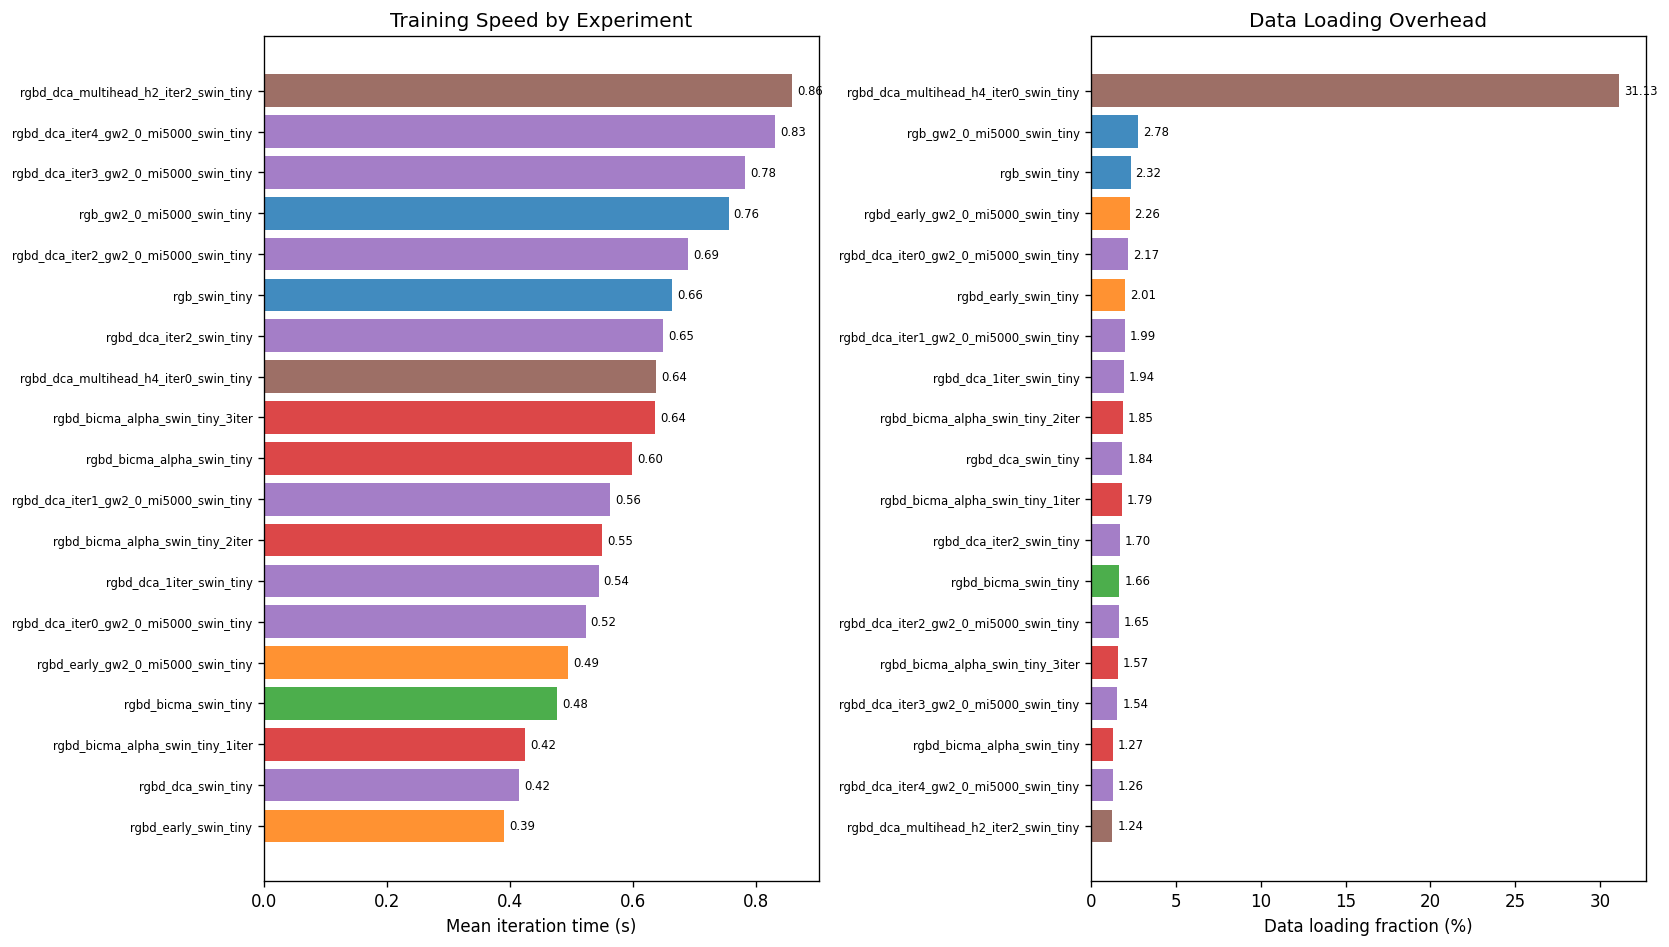

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, col, xlabel, title in [
    (axes[0], "mean_iter_time_s", "Mean iteration time (s)",   "Training Speed by Experiment"),
    (axes[1], "data_load_pct",    "Data loading fraction (%)", "Data Loading Overhead"),
]:
    sorted_df = eff_df.sort_values(col)
    colors_b  = [FAMILY_COLORS[f] for f in sorted_df["fusion"]]
    bars = ax.barh(sorted_df.index, sorted_df[col], color=colors_b, alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=7)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "training_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## Section C — COCO Evaluation (AP / AR)

In [8]:
STAT_NAMES = [
    "AP", "AP50", "AP75", "APs", "APm", "APl",
    "AR1", "AR10", "AR100", "ARs", "ARm", "ARl",
]


def run_coco_eval(exp_path: Path):
    gt_path = exp_path / "inference" / "rob2pheno_val_coco_format.json"
    dt_path = exp_path / "inference" / "coco_instances_results.json"
    if not gt_path.exists() or not dt_path.exists():
        return None
    buf = StringIO()
    with redirect_stdout(buf), redirect_stderr(buf):
        coco_gt   = COCO(str(gt_path))
        coco_dt   = coco_gt.loadRes(str(dt_path))
        coco_eval = COCOeval(coco_gt, coco_dt, iouType="segm")
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
    return coco_eval


coco_evals = {}
for exp_name, row in registry.iterrows():
    try:
        ev = run_coco_eval(row["path"])
        if ev is not None:
            coco_evals[exp_name] = ev
            print(f"  OK   {exp_name:<50}  AP={ev.stats[0]:.3f}  AP50={ev.stats[1]:.3f}")
        else:
            print(f"  SKIP {exp_name}  (no inference results)")
    except Exception as e:
        print(f"  ERR  {exp_name}  {e}")

print(f"\nEvaluated {len(coco_evals)}/{len(registry)} experiments")

  OK   rgb_gw2_0_mi5000_swin_tiny                          AP=0.541  AP50=0.783
  OK   rgb_swin_tiny                                       AP=0.553  AP50=0.807
  OK   rgbd_bicma_alpha_swin_tiny                          AP=0.573  AP50=0.855
  OK   rgbd_bicma_alpha_swin_tiny_1iter                    AP=0.556  AP50=0.830
  OK   rgbd_bicma_alpha_swin_tiny_2iter                    AP=0.567  AP50=0.836
  OK   rgbd_bicma_alpha_swin_tiny_3iter                    AP=0.570  AP50=0.848
  OK   rgbd_bicma_swin_tiny                                AP=0.130  AP50=0.346
  OK   rgbd_dca_1iter_swin_tiny                            AP=0.562  AP50=0.843
  OK   rgbd_dca_iter0_gw2_0_mi5000_swin_tiny               AP=0.562  AP50=0.828
  OK   rgbd_dca_iter1_gw2_0_mi5000_swin_tiny               AP=0.556  AP50=0.822
  OK   rgbd_dca_iter2_gw2_0_mi5000_swin_tiny               AP=0.568  AP50=0.852
  OK   rgbd_dca_iter2_swin_tiny                            AP=0.565  AP50=0.827
  OK   rgbd_dca_iter3_gw2_0_mi5000_swin_

In [9]:
coco_rows = []
for exp_name, ev in coco_evals.items():
    row = {"exp": exp_name}
    for i, s in enumerate(STAT_NAMES):
        row[s] = float(ev.stats[i])

    # Per-class AP — precision shape: [T, R, K, A, M]
    # T=10 IoU thresholds, R=101 recall pts, K=categories,
    # A=4 area ranges (0=all), M=3 maxdets (2=100)
    cat_ids   = ev.params.catIds
    cat_names = {c["id"]: c["name"] for c in ev.cocoGt.loadCats(cat_ids)}
    prec      = ev.eval["precision"]

    for k_idx, cat_id in enumerate(cat_ids):
        p_all = prec[:, :, k_idx, 0, 2]   # all IoU thresholds
        p_50  = prec[0,  :, k_idx, 0, 2]  # IoU=0.50 only
        cname = cat_names[cat_id]
        row[f"AP_{cname}"]   = float(np.mean(p_all[p_all > -1])) if (p_all > -1).any() else float("nan")
        row[f"AP50_{cname}"] = float(np.mean(p_50[p_50   > -1])) if (p_50  > -1).any() else float("nan")

    coco_rows.append(row)

coco_df = pd.DataFrame(coco_rows).set_index("exp")
coco_df = coco_df.join(registry[["modality", "fusion", "dca_iters", "heads", "gw"]])

display_cols = ["AP", "AP50", "AP75", "AR100",
                "AP_redfruit", "AP_greenfruit",
                "AP50_redfruit", "AP50_greenfruit"]
coco_df[display_cols].round(3).sort_values("AP50", ascending=False)

,AP,AP50,AP75,AR100,AP_redfruit,AP_greenfruit,AP50_redfruit,AP50_greenfruit
exp,,,,,,,,
rgbd_bicma_alpha_swin_tiny,0.573,0.855,0.661,0.634,0.609,0.537,0.893,0.818
rgbd_dca_iter2_gw2_0_mi5000_swin_tiny,0.568,0.852,0.654,0.627,0.598,0.538,0.889,0.814
rgbd_bicma_alpha_swin_tiny_3iter,0.570,0.848,0.659,0.625,0.618,0.522,0.899,0.798
rgbd_dca_swin_tiny,0.565,0.846,0.632,0.636,0.597,0.534,0.872,0.820
rgbd_dca_1iter_swin_tiny,0.562,0.843,0.640,0.632,0.599,0.525,0.885,0.801
rgbd_dca_iter3_gw2_0_mi5000_swin_tiny,0.562,0.838,0.644,0.622,0.591,0.532,0.881,0.795
rgbd_bicma_alpha_swin_tiny_2iter,0.567,0.836,0.655,0.623,0.597,0.538,0.866,0.806
rgbd_early_gw2_0_mi5000_swin_tiny,0.564,0.835,0.655,0.624,0.605,0.523,0.876,0.793
rgbd_bicma_alpha_swin_tiny_1iter,0.556,0.830,0.638,0.618,0.590,0.522,0.864,0.795


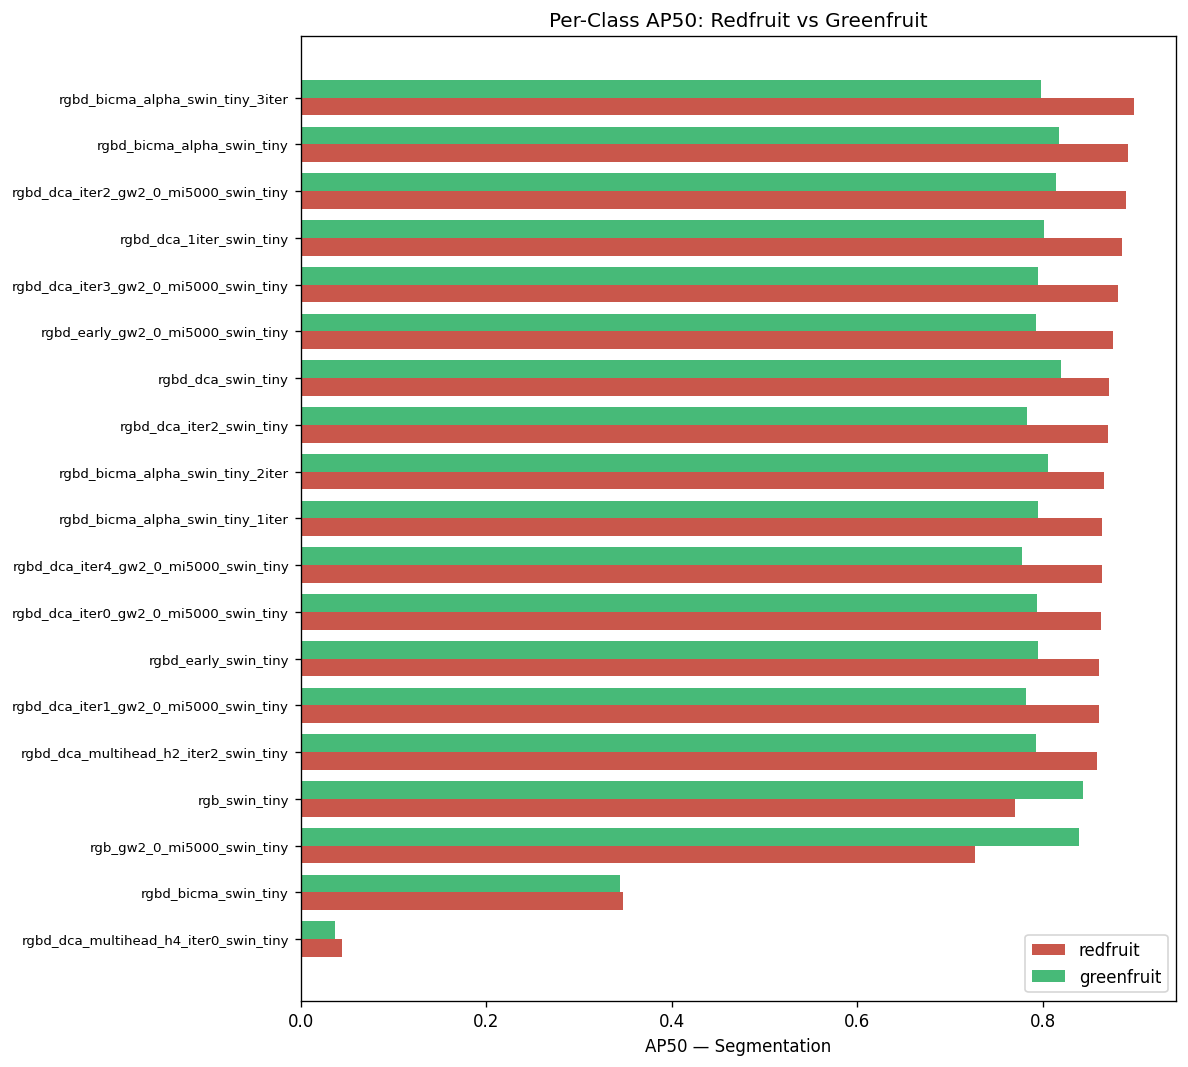

In [10]:
perclass = (
    coco_df[["AP50_redfruit", "AP50_greenfruit"]]
    .dropna()
    .sort_values("AP50_redfruit", ascending=True)
)
x = np.arange(len(perclass))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(x - width / 2, perclass["AP50_redfruit"],  width,
        label="redfruit",   color="#c0392b", alpha=0.85)
ax.barh(x + width / 2, perclass["AP50_greenfruit"], width,
        label="greenfruit", color="#27ae60", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(perclass.index, fontsize=8)
ax.set_xlabel("AP50 — Segmentation")
ax.set_title("Per-Class AP50: Redfruit vs Greenfruit")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "perclass_ap50.png", dpi=150, bbox_inches="tight")
plt.show()

## Section D — Summary Table & Heatmap

In [11]:
summary = (
    eff_df[["mean_iter_time_s", "total_train_h", "final_total_loss",
            "n_iters", "convergence_iter"]]
    .join(coco_df[["AP", "AP50", "AP75", "AR100",
                   "AP_redfruit", "AP_greenfruit"]], how="left")
    .join(registry[["modality", "fusion", "dca_iters", "heads", "gw"]])
)

show_cols = [
    "fusion", "modality", "dca_iters", "heads", "gw",
    "AP", "AP50", "AP75", "AR100",
    "AP_redfruit", "AP_greenfruit",
    "final_total_loss", "mean_iter_time_s", "total_train_h",
]


def _fmt(x, fmt):
    return fmt % x if pd.notna(x) else "-"


styled = (
    summary[show_cols]
    .sort_values("AP50", ascending=False, na_position="last")
    .style
    .background_gradient(
        subset=["AP", "AP50", "AP75", "AR100", "AP_redfruit", "AP_greenfruit"],
        cmap="RdYlGn", axis=0)
    .background_gradient(
        subset=["final_total_loss", "mean_iter_time_s"],
        cmap="RdYlGn_r", axis=0)
    .format({
        "AP":              lambda x: _fmt(x, "%.3f"),
        "AP50":            lambda x: _fmt(x, "%.3f"),
        "AP75":            lambda x: _fmt(x, "%.3f"),
        "AR100":           lambda x: _fmt(x, "%.3f"),
        "AP_redfruit":     lambda x: _fmt(x, "%.3f"),
        "AP_greenfruit":   lambda x: _fmt(x, "%.3f"),
        "final_total_loss":lambda x: _fmt(x, "%.2f"),
        "mean_iter_time_s":lambda x: _fmt(x, "%.3f") + "s",
        "total_train_h":   lambda x: _fmt(x, "%.2f") + "h",
        "gw":              lambda x: _fmt(x, "%.1f"),
        "dca_iters":       lambda x: str(int(x)) if pd.notna(x) else "-",
        "heads":           lambda x: str(int(x)) if pd.notna(x) else "-",
    })
)
styled

,fusion,modality,dca_iters,heads,gw,AP,AP50,AP75,AR100,AP_redfruit,AP_greenfruit,final_total_loss,mean_iter_time_s,total_train_h
exp,,,,,,,,,,,,,,
rgbd_bicma_alpha_swin_tiny,bicma_alpha,rgbd,-,-,-,0.573,0.855,0.661,0.634,0.609,0.537,4.48,0.598s,0.08h
rgbd_dca_iter2_gw2_0_mi5000_swin_tiny,dca,rgbd,2,-,2.0,0.568,0.852,0.654,0.627,0.598,0.538,3.51,0.689s,0.05h
rgbd_bicma_alpha_swin_tiny_3iter,bicma_alpha,rgbd,3,-,-,0.570,0.848,0.659,0.625,0.618,0.522,4.28,0.636s,0.04h
rgbd_dca_swin_tiny,dca,rgbd,-,-,-,0.565,0.846,0.632,0.636,0.597,0.534,4.96,0.415s,0.09h
rgbd_dca_1iter_swin_tiny,dca,rgbd,1,-,-,0.562,0.843,0.640,0.632,0.599,0.525,3.82,0.544s,0.04h
rgbd_dca_iter3_gw2_0_mi5000_swin_tiny,dca,rgbd,3,-,2.0,0.562,0.838,0.644,0.622,0.591,0.532,3.70,0.782s,0.05h
rgbd_bicma_alpha_swin_tiny_2iter,bicma_alpha,rgbd,2,-,-,0.567,0.836,0.655,0.623,0.597,0.538,3.96,0.549s,0.04h
rgbd_early_gw2_0_mi5000_swin_tiny,early,rgbd,-,-,2.0,0.564,0.835,0.655,0.624,0.605,0.523,3.72,0.494s,0.03h
rgbd_bicma_alpha_swin_tiny_1iter,bicma_alpha,rgbd,1,-,-,0.556,0.830,0.638,0.618,0.590,0.522,3.84,0.424s,0.03h


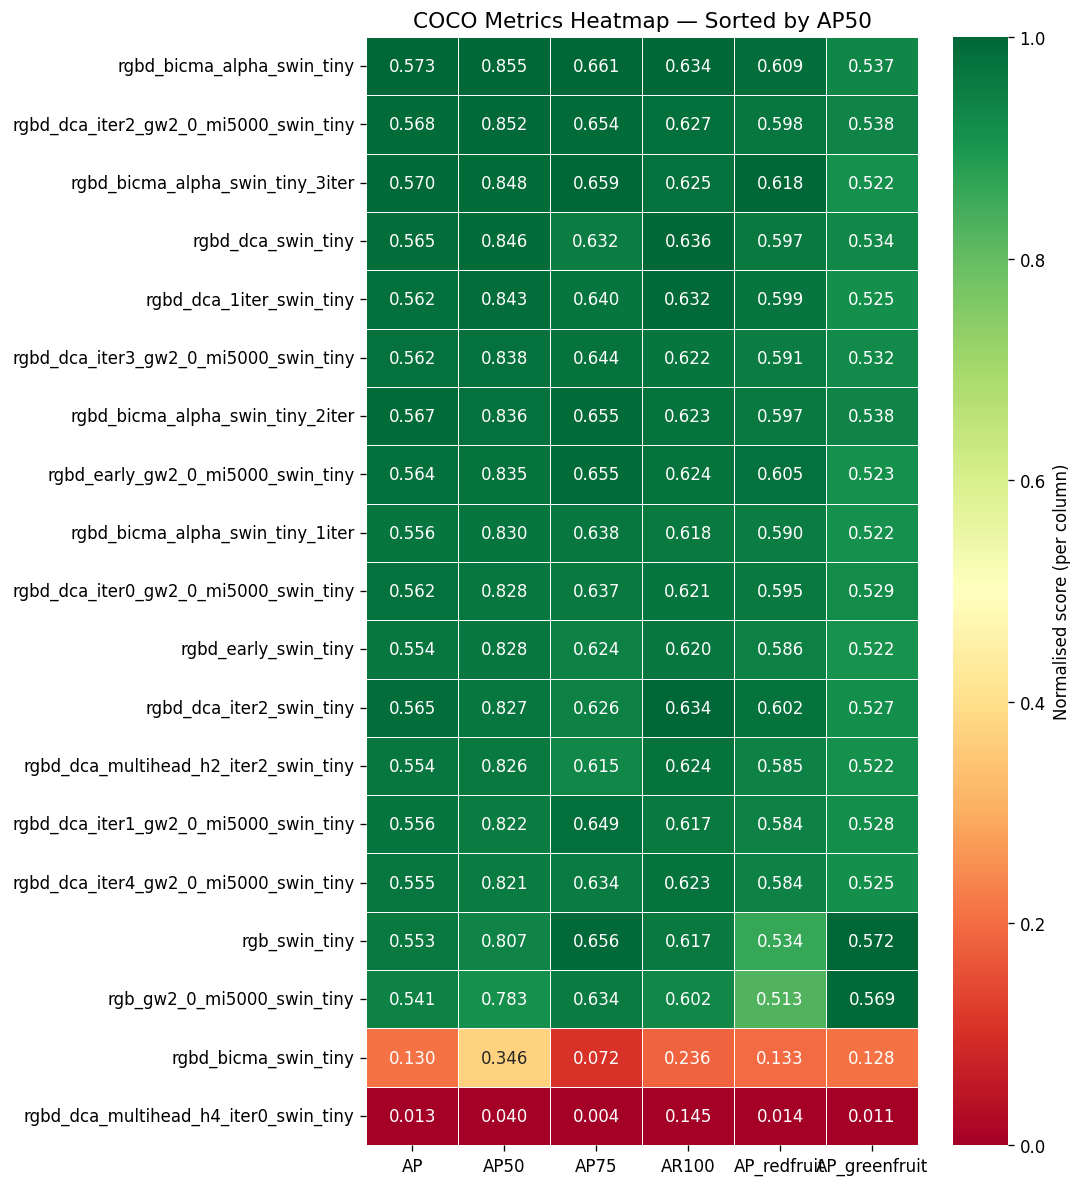

In [12]:
heatmap_cols = ["AP", "AP50", "AP75", "AR100", "AP_redfruit", "AP_greenfruit"]
hm_data = (
    coco_df[heatmap_cols]
    .dropna(subset=["AP50"])
    .sort_values("AP50", ascending=False)
)
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-8)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(
    hm_norm, annot=hm_data.round(3), fmt=".3f",
    cmap="RdYlGn", ax=ax, linewidths=0.5,
    cbar_kws={"label": "Normalised score (per column)"},
    vmin=0, vmax=1,
)
ax.set_title("COCO Metrics Heatmap — Sorted by AP50", fontsize=13)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

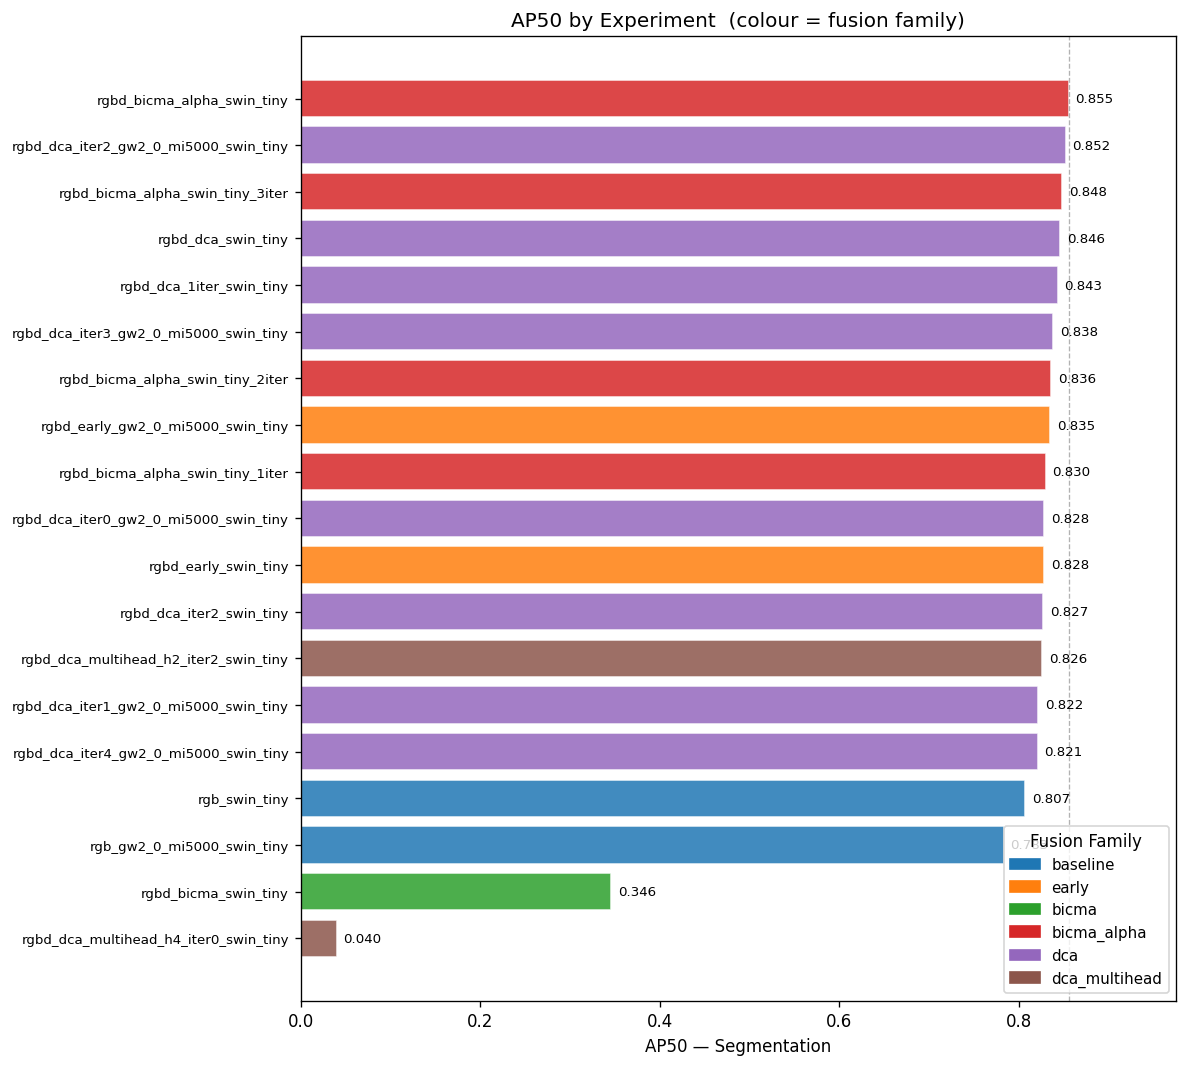

In [13]:
ap50 = coco_df["AP50"].dropna().sort_values(ascending=True)
colors_b = [FAMILY_COLORS[registry.loc[e, "fusion"]] for e in ap50.index]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(ap50.index, ap50.values, color=colors_b, alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)
ax.set_xlabel("AP50 — Segmentation")
ax.set_title("AP50 by Experiment  (colour = fusion family)")
ax.set_xlim(0, min(ap50.max() * 1.14, 1.0))
ax.tick_params(axis="y", labelsize=8)
ax.axvline(ap50.max(), color="gray", ls="--", lw=0.8, alpha=0.6, label="Best")

handles = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
ax.legend(handles=handles, loc="lower right", title="Fusion Family", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "ap50_comparison.png", dpi=150, bbox_inches="tight")
plt.show()